# Self-supervised pre-training enables marine debris detection across sensors
This code allows to download the benchmark dataset with its associated binary annotations.

## Original dataset
Shah, A., Thomas, L., & Maskey, M. (2021) "Marine Debris Dataset for Object Detection in Planetscope Imagery", Version 1.0, Radiant MLHub. https://doi.org/10.34911/rdnt.9r6ekg

## Benchmark for binary segmentation
Emanuele Dalsasso, Marc Rußwurm, Christian Donner, Samuel Darmon, Robin de Vries, Michele Volpi, Devis Tuia,
Self-supervised pre-training enables marine debris detection across sensors,
Remote Sensing of Environment,
Volume 339,
2026,
115391,
ISSN 0034-4257,
https://doi.org/10.1016/j.rse.2026.115391.

```
@article{DALSASSO2026115391,
title = {Self-supervised pre-training enables marine debris detection across sensors},
journal = {Remote Sensing of Environment},
volume = {339},
pages = {115391},
year = {2026},
issn = {0034-4257},
doi = {https://doi.org/10.1016/j.rse.2026.115391},
url = {https://www.sciencedirect.com/science/article/pii/S0034425726001616},
author = {Emanuele Dalsasso and Marc Rußwurm and Christian Donner and Samuel Darmon and Robin {de Vries} and Michele Volpi and Devis Tuia},
}
```

## 1. Download the dataset
This step downloads the zip archive containing both the [original dataset](https://source.coop/nasa/marine-debris) and the pixel-level binary annotations. In our training strategy, some images where left out to include them in the training set. The dataset contains the `.json` files indicating the splits used in our paper. A Pytorch dataloader already considers the split used in the paper and loads the validation images.

In [ ]:
!wget -O dataset.zip https://osf.io/ha3fb/download
!unzip dataset.zip

## 2. Val dataloader

In [30]:
import torch
import os
import numpy as np
import json

class PlanetValDataset(torch.utils.data.Dataset):
    def __init__(self, folder, split_cross_val):
        self.folder = folder
        self.split_cross_val = split_cross_val

        # load json file with split: 'val_images_fold_' indicated that the validation images are loaded
        with open(os.path.join(self.folder, 'val_images_fold_'+str(self.split_cross_val)+'.json')) as f:
            self.file_names = json.load(f)

        # remove from file_names the images for which the labels are not available (just a check)
        self.file_names = [f for f in self.file_names if os.path.exists(os.path.join(self.folder, 'full_dataset/labels/'+f.replace('_patch_0_0','')))]

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        img_file_path = os.path.join(self.folder, 'full_dataset/images/'+self.file_names[idx])
        label_file_path = os.path.join(self.folder, 'full_dataset/labels/'+self.file_names[idx].replace('_patch_0_0',''))
        # images have previously been normalized and can directly be loaded
        img = np.load(img_file_path).astype(np.float32)
        img = img.transpose(2, 0, 1) # from H,W,C to C,H,W

        label = np.load(label_file_path).astype(np.float32)
        label = np.expand_dims(label, 0) # C=1

        return torch.from_numpy(img), torch.from_numpy(label), self.file_names[idx]


In [31]:
planet_loader = PlanetValDataset('/content/dataset/',1)
planet_val_loader = torch.utils.data.DataLoader(planet_loader, batch_size=30, shuffle=False)

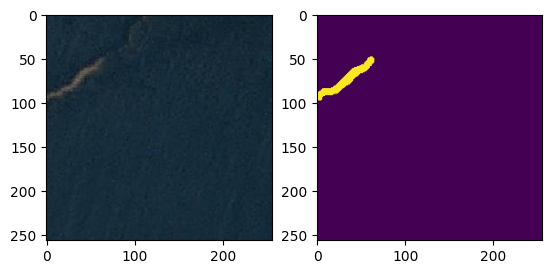

In [32]:
# iterate on the val loader
it = iter(planet_val_loader)
y, l, metadata = next(it)

import matplotlib.pyplot as plt

# select one item from the batch and plot it
i=3

# plot the image and the associated binary label
plt.figure()
plt.subplot(121)
plt.imshow((y.numpy()[i]).transpose(1,2,0))
plt.subplot(122)
plt.imshow((l.numpy()[i]).transpose(1,2,0))
plt.show()